In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt


# Student Performance Dataset - Data Dictionary and Data Cleaning

This notebook documents the Student Performance dataset, performs duplicate detection, analyzes missing values, applies data cleaning, and exports a cleaned version of the dataset.


## Dictionary

In [3]:

dictionary_data = [
    ["Hours_Studied", "Number of hours the student studied", "Numerical", "Hours", ">= 0", "Possible outliers or unrealistic values"],
    ["Attendance", "Attendance percentage of the student", "Numerical", "Percentage (%)", "0 to 100", "Values outside range or inconsistent decimals"],
    ["Parental_Involvement", "Level of parental involvement in education", "Categorical", "-", "Low / Medium / High", "Inconsistent labeling or typos"],
    ["Access_to_Resources", "Level of access to learning resources", "Categorical", "-", "Low / Medium / High", "Subjective categorization"],
    ["Extracurricular_Activities", "Participation in extracurricular activities", "Categorical", "-", "Yes / No", "Encoding required for modeling"],
    ["Sleep_Hours", "Average daily sleep hours", "Numerical", "Hours", "0 to 24", "Outliers or unrealistic values"],
    ["Previous_Scores", "Student's previous academic scores", "Numerical", "Score", "0 to 100", "Outliers or inconsistent scaling"],
    ["Motivation_Level", "Level of student motivation", "Categorical", "-", "Low / Medium / High", "Subjective and ordinal variable"],
    ["Internet_Access", "Whether the student has internet access", "Categorical", "-", "Yes / No", "Needs encoding"],
    ["Tutoring_Sessions", "Number of tutoring sessions attended", "Numerical", "Count", ">= 0", "Skewed distribution (many zeros)"],
    ["Final_Exam_Score", "Final exam score achieved by the student", "Numerical", "Score", "0 to 100", "Target variable; possible outliers"],
]

dictionary_columns = [
    "Name",
    "Description (Semantic Meaning)",
    "Data Type",
    "Units",
    "Possible Values / Categories",
    "Potential Data Quality Issues",
]

df_dictionary = pd.DataFrame(dictionary_data, columns=dictionary_columns)

pd.set_option("display.max_colwidth", None)
display(df_dictionary)

df_dictionary.to_csv("student_dictionary.csv", index=False)
print("Dictionary saved as: student_dictionary.csv")

,Name,Description (Semantic Meaning),Data Type,Units,Possible Values / Categories,Potential Data Quality Issues
0,Hours_Studied,Number of hours the student studied,Numerical,Hours,>= 0,Possible outliers or unrealistic values
1,Attendance,Attendance percentage of the student,Numerical,Percentage (%),0 to 100,Values outside range or inconsistent decimals
2,Parental_Involvement,Level of parental involvement in education,Categorical,-,Low / Medium / High,Inconsistent labeling or typos
3,Access_to_Resources,Level of access to learning resources,Categorical,-,Low / Medium / High,Subjective categorization
4,Extracurricular_Activities,Participation in extracurricular activities,Categorical,-,Yes / No,Encoding required for modeling
5,Sleep_Hours,Average daily sleep hours,Numerical,Hours,0 to 24,Outliers or unrealistic values
6,Previous_Scores,Student's previous academic scores,Numerical,Score,0 to 100,Outliers or inconsistent scaling
7,Motivation_Level,Level of student motivation,Categorical,-,Low / Medium / High,Subjective and ordinal variable
8,Internet_Access,Whether the student has internet access,Categorical,-,Yes / No,Needs encoding
9,Tutoring_Sessions,Number of tutoring sessions attended,Numerical,Count,>= 0,Skewed distribution (many zeros)


Dictionary saved as: student_dictionary.csv


## Load Student Performance Dataset

In [4]:

dataset_file = "student_dataset.csv"

if not os.path.exists(dataset_file):
    raise FileNotFoundError(f"{dataset_file} not found")

df = pd.read_csv(dataset_file)

print(f"Loaded file: {dataset_file}")
print(f"Dataset shape before cleaning: {df.shape}")
display(df.head())

Loaded file: student_dataset.csv
Dataset shape before cleaning: (6607, 11)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7


## Duplicate Detection and Handling

**Detection Strategy:**  
Since this dataset does not contain a unique identifier column, duplicate detection is based on full-row comparison. If all values in a row are repeated, that row is considered a duplicate.

**Consolidation Method:**  
If duplicate rows are found, the chosen method is removal while keeping the first occurrence. This avoids overrepresenting the same student record in future analyses.


In [5]:
# Identifying exact row duplicates
exact_duplicates = df.duplicated().sum()
print(f"Exact row duplicates: {exact_duplicates}")

# Removing duplicates
df_cleaned = df.drop_duplicates().copy()

print(f"Dataset after removing duplicates: {df_cleaned.shape}")

df_cleaned.to_csv("student_after_duplicate_removal.csv", index=False)
print("Intermediate file saved as: student_after_duplicate_removal.csv")

Exact row duplicates: 0
Dataset after removing duplicates: (6607, 11)
Intermediate file saved as: student_after_duplicate_removal.csv


## Missing Data Treatment

In [6]:
# Missing values per variable
missing_per_variable = df_cleaned.isnull().sum()
print("Missing values per variable:")
print(missing_per_variable[missing_per_variable > 0])

# Missing values overall
total_missing = df_cleaned.isnull().sum().sum()
print(f"\nTotal missing values in the dataset: {total_missing}")

Missing values per variable:
Series([], dtype: int64)

Total missing values in the dataset: 0


**Data Missing Patterns:**  
If missing values are found, they may occur either in numerical variables (for example, study hours or previous scores) or in categorical variables (for example, motivation level or internet access).

**Treatment Strategy and Justification:**  
- Numerical variables are filled with the **median**, since it is robust to outliers.  
- Categorical variables are filled with the **mode** (most frequent value), which preserves the most common category.  

This strategy preserves the largest possible number of records without introducing excessive distortion into the dataset.


In [7]:
# Separating numerical and categorical columns
numerical_cols = df_cleaned.select_dtypes(include=["number"]).columns
categorical_cols = df_cleaned.select_dtypes(exclude=["number"]).columns

# Filling missing numerical values with median
for col in numerical_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Filling missing categorical values with mode
for col in categorical_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print(f"Total missing values after treatment: {df_cleaned.isnull().sum().sum()}")
print(f"\nDataset after cleaning: {df_cleaned.shape}")

df_cleaned.to_csv("student_performance_cleaned.csv", index=False)
print("Final cleaned file saved as: student_performance_cleaned.csv")

Total missing values after treatment: 0

Dataset after cleaning: (6607, 11)
Final cleaned file saved as: student_performance_cleaned.csv


## Optional Quality Checks

The following cell checks whether numerical values are within plausible ranges for this dataset.


In [8]:
quality_checks = {}

if "Attendance" in df_cleaned.columns:
    quality_checks["Attendance_out_of_range"] = ((df_cleaned["Attendance"] < 0) | (df_cleaned["Attendance"] > 100)).sum()

if "Sleep_Hours" in df_cleaned.columns:
    quality_checks["Sleep_Hours_out_of_range"] = ((df_cleaned["Sleep_Hours"] < 0) | (df_cleaned["Sleep_Hours"] > 24)).sum()

if "Previous_Scores" in df_cleaned.columns:
    quality_checks["Previous_Scores_out_of_range"] = ((df_cleaned["Previous_Scores"] < 0) | (df_cleaned["Previous_Scores"] > 100)).sum()

if "Final_Exam_Score" in df_cleaned.columns:
    quality_checks["Final_Exam_Score_out_of_range"] = ((df_cleaned["Final_Exam_Score"] < 0) | (df_cleaned["Final_Exam_Score"] > 100)).sum()

print("Quality checks:")
for key, value in quality_checks.items():
    print(f"{key}: {value}")

Quality checks:
Attendance_out_of_range: 0
Sleep_Hours_out_of_range: 0
Previous_Scores_out_of_range: 0
Final_Exam_Score_out_of_range: 0


## Final Statement

The dataset was preprocessed by documenting its variables, checking for duplicate rows, analyzing missing values, and applying cleaning strategies. Exact duplicates were removed when present. Missing numerical values were treated using median imputation, while missing categorical values were filled with the mode. The cleaned dataset was then exported for future analysis and modeling.


# Student Performance Dataset - Exploratory Data Analysis

This notebook extends the cleaned Student Performance dataset analysis by creating grouped summaries, distribution plots, category comparisons, correlation analysis, and visual comparisons between different student profiles.

The main objective is to understand how study habits, attendance, previous scores, sleep hours, motivation, parental involvement, access to resources, internet access, and tutoring sessions relate to the final exam score.

## Step 1: Import Libraries

In [2]:

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## Step 2: Load Dataset

In [3]:

# Prefer the cleaned dataset if it exists.
dataset_file = "student_cleaned.csv"

# Fallback to the original dataset if needed.
if not os.path.exists(dataset_file):
    dataset_file = "student_dataset.csv"

if not os.path.exists(dataset_file):
    raise FileNotFoundError("Neither student_cleaned.csv nor student_dataset.csv was found.")

df = pd.read_csv(dataset_file)

print(f"Loaded file: {dataset_file}")
print(f"Dataset shape: {df.shape}")

display(df.head())

Loaded file: student_cleaned.csv
Dataset shape: (6607, 11)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7


## Step 3: Structural Diagnosis

In [4]:
print("Dataset information:")
df.info()

print("\nMissing values per column:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicated rows:")
print(df.duplicated().sum())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   float64
 1   Attendance                  6607 non-null   float64
 2   Parental_Involvement        6607 non-null   str    
 3   Access_to_Resources         6607 non-null   str    
 4   Extracurricular_Activities  6607 non-null   str    
 5   Sleep_Hours                 6607 non-null   float64
 6   Previous_Scores             6607 non-null   float64
 7   Motivation_Level            6607 non-null   str    
 8   Internet_Access             6607 non-null   str    
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Final_Exam_Score            6607 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 567.9 KB

Missing values per column:


,missing_values
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0



Duplicated rows:
0


## Step 4: Descriptive Statistics

In [5]:
numeric_summary = df.describe().T
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,20.472726,5.988729,1.1,16.5,20.5,24.5,44.0
Attendance,6607.0,79.979068,11.547717,60.0,70.0,79.8,90.2,100.0
Sleep_Hours,6607.0,7.185273,1.290241,4.0,6.3,7.2,8.1,10.0
Previous_Scores,6607.0,74.716059,14.451962,50.0,62.1,74.6,87.4,100.0
Tutoring_Sessions,6607.0,1.488119,1.216175,0.0,1.0,1.0,2.0,8.0
Final_Exam_Score,6607.0,60.400333,8.739400,29.7,54.3,60.4,66.6,95.2


## Step 5: Create Study Hour Groups

The variable `Hours_Studied` is converted into study ranges.  
This allows comparison of average final exam performance across different levels of study time.

In [6]:
bins = [0, 10, 20, 30, 40, np.inf]
labels = ['0-9', '10-19', '20-29', '30-39', '40+']

df['Study_Hours_Group'] = pd.cut(
    df['Hours_Studied'],
    bins=bins,
    labels=labels,
    right=False
)

print("Study hour groups:")
print(df['Study_Hours_Group'].value_counts().sort_index())
display(df.head())

Study hour groups:
Study_Hours_Group
0-9       268
10-19    2796
20-29    3160
30-39     380
40+         3
Name: count, dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score,Study_Hours_Group
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3,20-29
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4,10-19
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8,20-29
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0,20-29
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7,10-19


## Step 6: Aggregated Table by Study Hour Group

In [7]:
study_group_summary = (
    df.groupby('Study_Hours_Group', observed=True)
    .agg(
        student_count=('Final_Exam_Score', 'count'),
        avg_exam_score=('Final_Exam_Score', 'mean'),
        avg_attendance=('Attendance', 'mean'),
        avg_sleep=('Sleep_Hours', 'mean'),
        avg_previous_score=('Previous_Scores', 'mean'),
        avg_tutoring_sessions=('Tutoring_Sessions', 'mean')
    )
    .reset_index()
)

display(study_group_summary)

,Study_Hours_Group,student_count,avg_exam_score,avg_attendance,avg_sleep,avg_previous_score,avg_tutoring_sessions
0,0-9,268,52.105224,80.164925,7.371642,73.313806,1.585821
1,10-19,2796,57.815272,80.054971,7.203362,74.916702,1.474249
2,20-29,3160,62.587753,79.912057,7.153354,74.733101,1.492722
3,30-39,380,66.997632,79.834474,7.191316,74.126316,1.476316
4,40+,3,70.966667,81.533333,6.533333,69.733333,2.333333


## Step 7: Aggregated Tables by Categorical Variables

In [8]:
categorical_columns = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Extracurricular_Activities',
    'Motivation_Level',
    'Internet_Access'
]

category_summaries = {}

for col in categorical_columns:
    summary = (
        df.groupby(col, observed=True)
        .agg(
            student_count=('Final_Exam_Score', 'count'),
            avg_exam_score=('Final_Exam_Score', 'mean'),
            avg_hours_studied=('Hours_Studied', 'mean'),
            avg_attendance=('Attendance', 'mean'),
            avg_previous_score=('Previous_Scores', 'mean')
        )
        .reset_index()
        .sort_values('avg_exam_score', ascending=False)
    )

    category_summaries[col] = summary
    print(f"\nSummary by {col}:")
    display(summary)


Summary by Parental_Involvement:


,Parental_Involvement,student_count,avg_exam_score,avg_hours_studied,avg_attendance,avg_previous_score
1,Low,1274,60.499372,20.548352,80.148509,74.530220
2,Medium,3365,60.449747,20.464428,79.914294,75.116850
0,High,1968,60.251728,20.437957,79.980132,74.151067



Summary by Access_to_Resources:


,Access_to_Resources,student_count,avg_exam_score,avg_hours_studied,avg_attendance,avg_previous_score
0,High,1979,62.258110,20.527388,79.962052,74.878221
2,Medium,3349,60.103016,20.453867,79.811287,74.621200
1,Low,1279,58.304300,20.437529,80.444722,74.713526



Summary by Extracurricular_Activities:


,Extracurricular_Activities,student_count,avg_exam_score,avg_hours_studied,avg_attendance,avg_previous_score
1,Yes,3988,60.609529,20.518957,80.172292,74.935532
0,No,2619,60.081787,20.402329,79.684842,74.381863



Summary by Motivation_Level:


,Motivation_Level,student_count,avg_exam_score,avg_hours_studied,avg_attendance,avg_previous_score
0,High,1336,63.938473,20.614521,79.822380,75.003892
2,Medium,3386,60.595747,20.462374,80.005582,74.741731
1,Low,1885,57.541645,20.390822,80.042493,74.465942



Summary by Internet_Access:


,Internet_Access,student_count,avg_exam_score,avg_hours_studied,avg_attendance,avg_previous_score
1,Yes,6093,60.409732,20.492483,79.925734,74.689299
0,No,514,60.288911,20.238521,80.611284,75.033268


## Step 8: Distribution of Final Exam Score

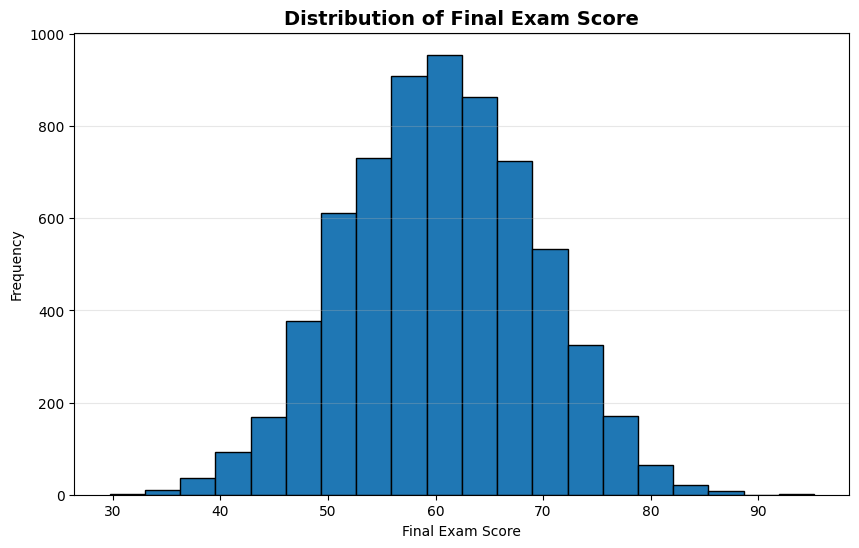

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df['Final_Exam_Score'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of Final Exam Score', fontsize=14, fontweight='bold')
plt.xlabel('Final Exam Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Step 9: Distribution of Study Hours, Attendance and Sleep Hours

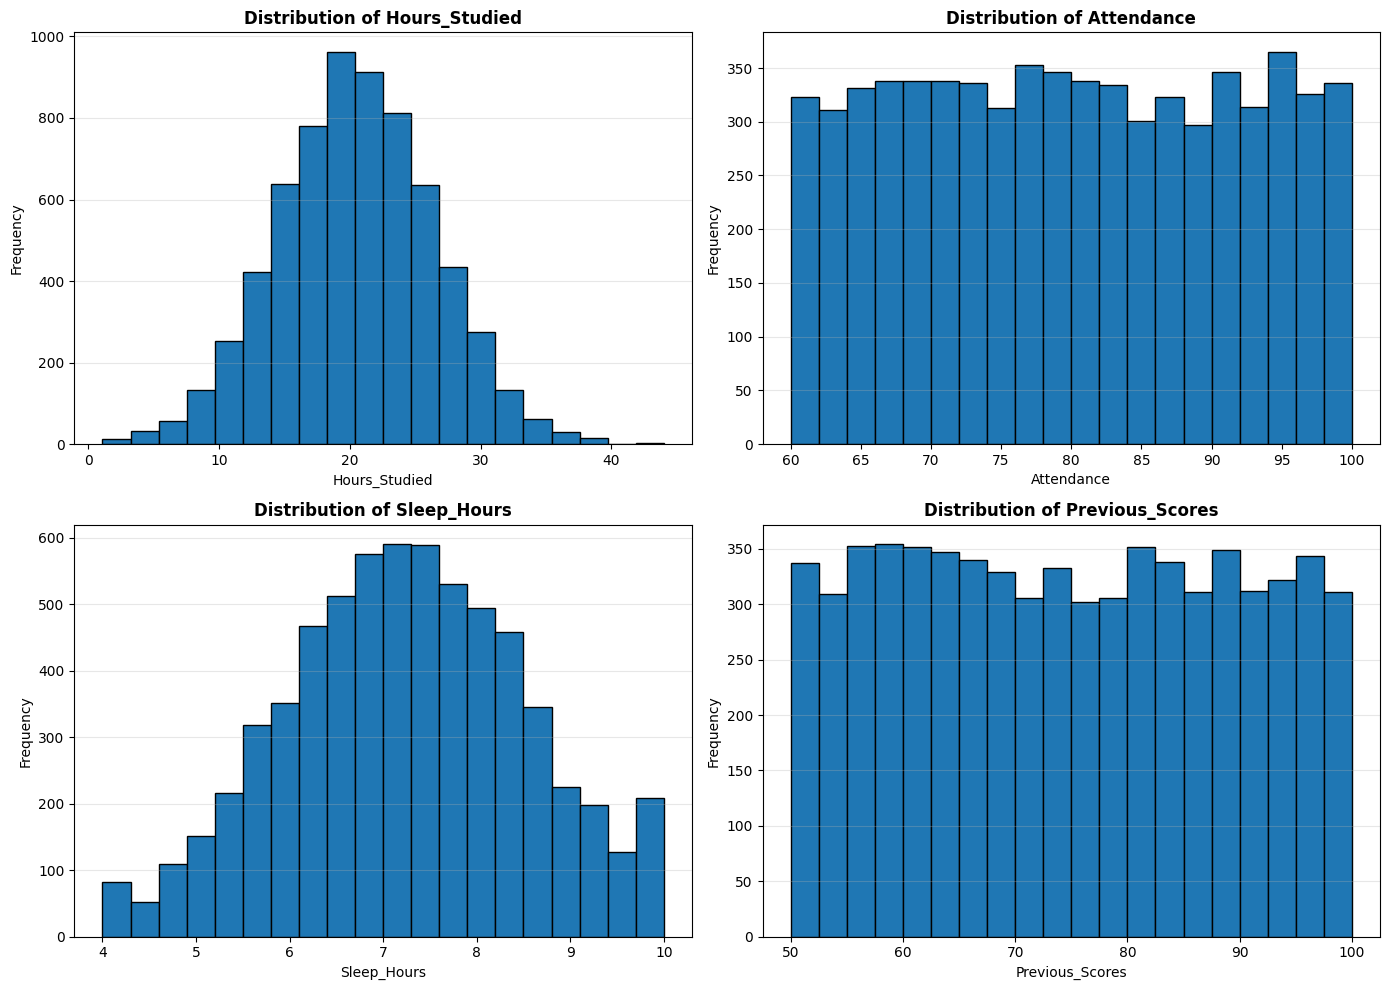

In [10]:
numeric_columns_to_plot = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']

ncols = 2
nrows = int(np.ceil(len(numeric_columns_to_plot) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_columns_to_plot):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=20, edgecolor='black')
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Step 10: Average Final Exam Score by Study Hour Group

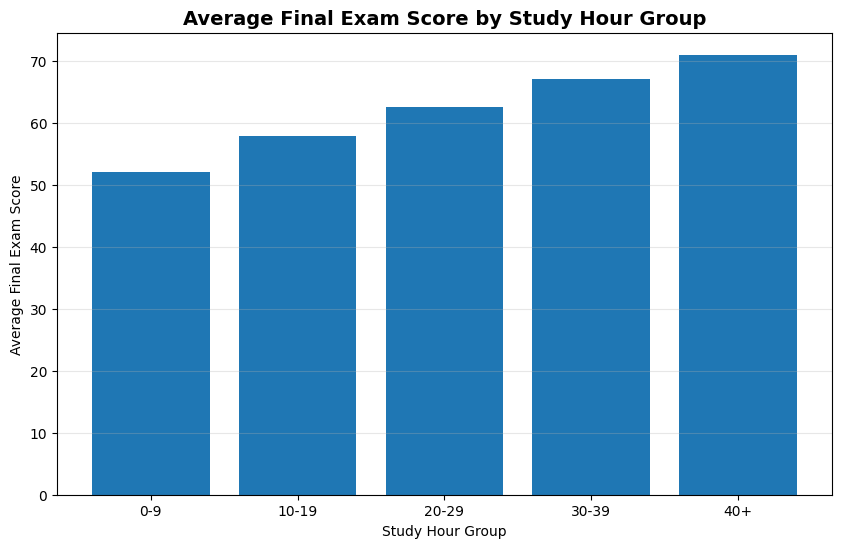

In [11]:
plt.figure(figsize=(10, 6))
plt.bar(
    study_group_summary['Study_Hours_Group'].astype(str),
    study_group_summary['avg_exam_score']
)
plt.title('Average Final Exam Score by Study Hour Group', fontsize=14, fontweight='bold')
plt.xlabel('Study Hour Group')
plt.ylabel('Average Final Exam Score')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Step 11: Average Final Exam Score by Motivation Level

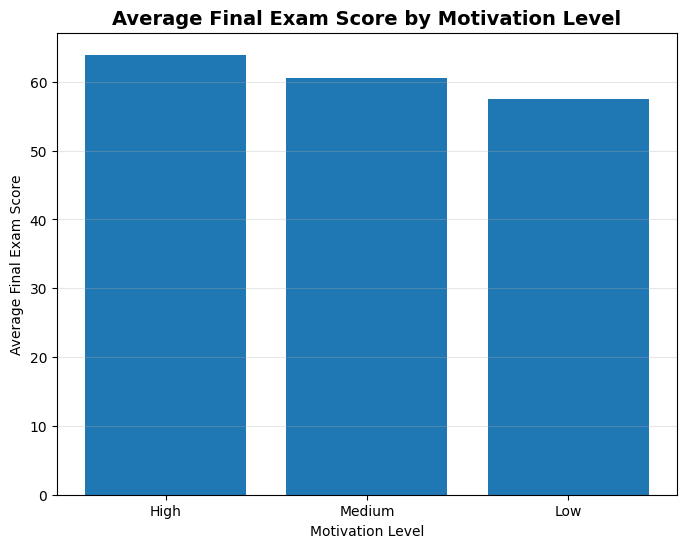

In [12]:
motivation_summary = category_summaries['Motivation_Level']

plt.figure(figsize=(8, 6))
plt.bar(
    motivation_summary['Motivation_Level'].astype(str),
    motivation_summary['avg_exam_score']
)
plt.title('Average Final Exam Score by Motivation Level', fontsize=14, fontweight='bold')
plt.xlabel('Motivation Level')
plt.ylabel('Average Final Exam Score')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Step 12: Average Final Exam Score by Access to Resources

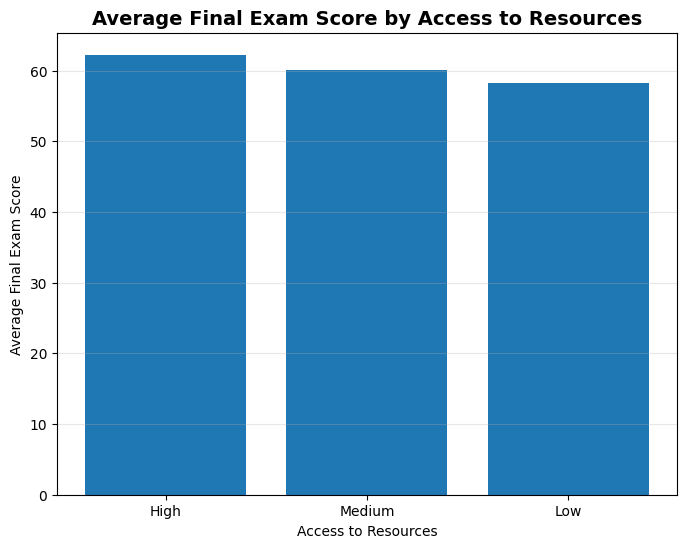

In [13]:
resources_summary = category_summaries['Access_to_Resources']

plt.figure(figsize=(8, 6))
plt.bar(
    resources_summary['Access_to_Resources'].astype(str),
    resources_summary['avg_exam_score']
)
plt.title('Average Final Exam Score by Access to Resources', fontsize=14, fontweight='bold')
plt.xlabel('Access to Resources')
plt.ylabel('Average Final Exam Score')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Step 13: Comparison Between Students With and Without Internet Access

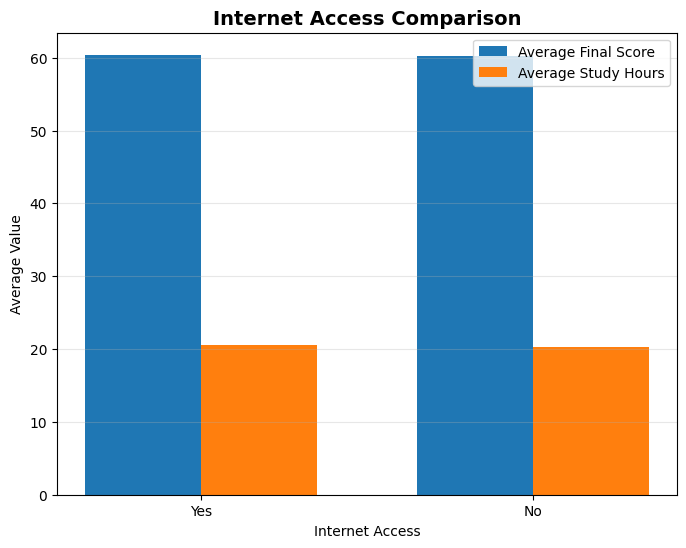

,Internet_Access,student_count,avg_exam_score,avg_hours_studied,avg_attendance,avg_previous_score
1,Yes,6093,60.409732,20.492483,79.925734,74.689299
0,No,514,60.288911,20.238521,80.611284,75.033268


In [14]:
internet_summary = category_summaries['Internet_Access']

x = np.arange(len(internet_summary))
width = 0.35

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, internet_summary['avg_exam_score'], width, label='Average Final Score')
plt.bar(x + width/2, internet_summary['avg_hours_studied'], width, label='Average Study Hours')

plt.title('Internet Access Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Internet Access')
plt.ylabel('Average Value')
plt.xticks(x, internet_summary['Internet_Access'].astype(str))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

display(internet_summary)

## Step 14: Scatter Plot - Study Hours vs Final Exam Score

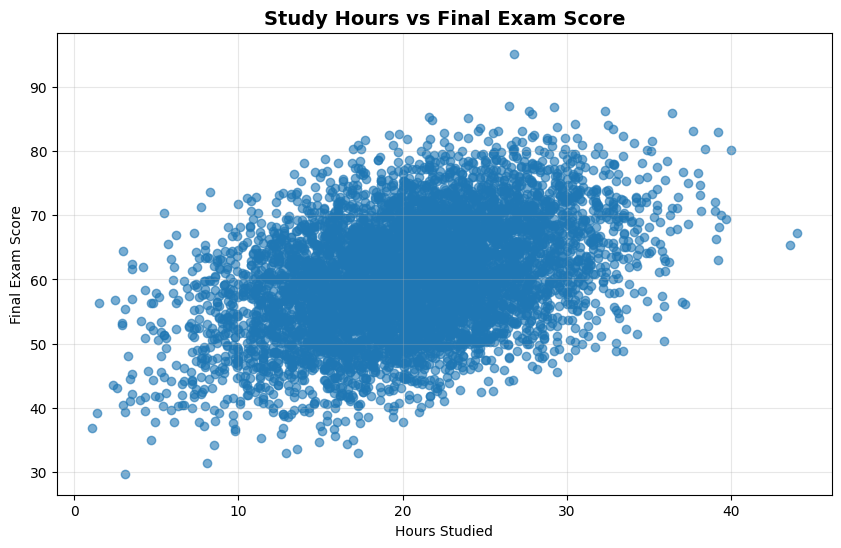

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Hours_Studied'], df['Final_Exam_Score'], alpha=0.6)
plt.title('Study Hours vs Final Exam Score', fontsize=14, fontweight='bold')
plt.xlabel('Hours Studied')
plt.ylabel('Final Exam Score')
plt.grid(alpha=0.3)
plt.show()

## Step 15: Scatter Plot - Attendance vs Final Exam Score

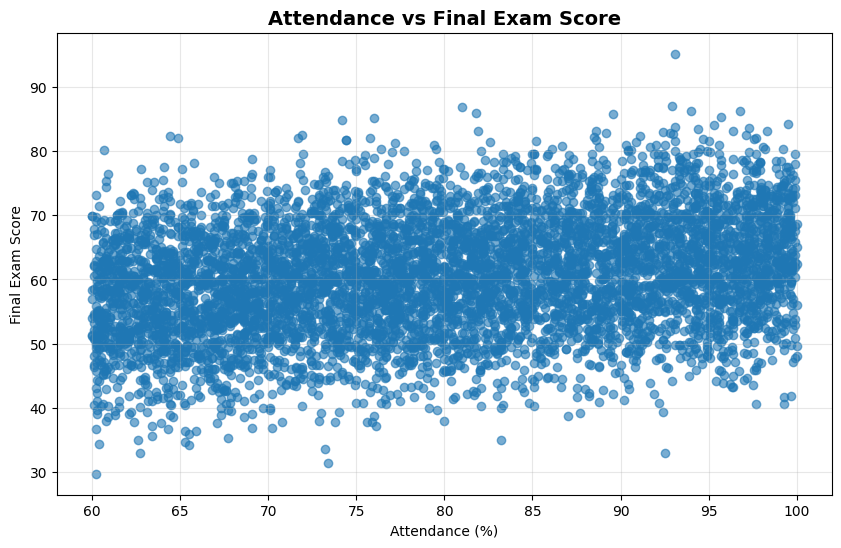

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Attendance'], df['Final_Exam_Score'], alpha=0.6)
plt.title('Attendance vs Final Exam Score', fontsize=14, fontweight='bold')
plt.xlabel('Attendance (%)')
plt.ylabel('Final Exam Score')
plt.grid(alpha=0.3)
plt.show()

## Step 16: Boxplot of Final Exam Score by Motivation Level

/var/folders/39/m1sx67zs48zcs_1sl5yg1lmw0000gn/T/ipykernel_36653/463668549.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=existing_order)


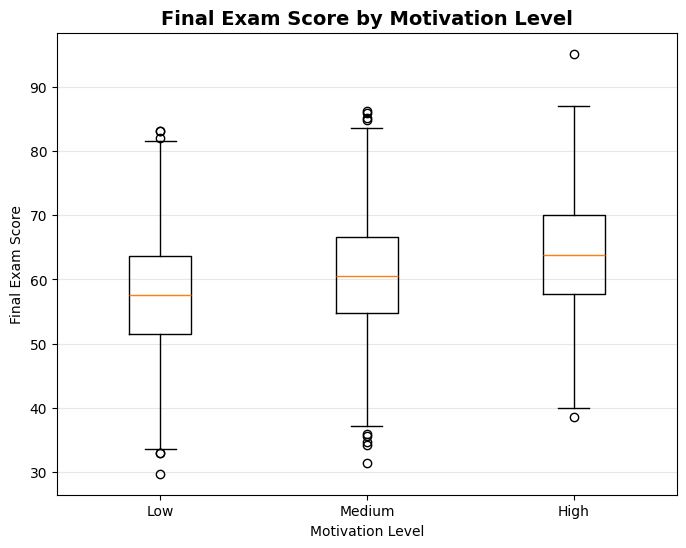

In [17]:
motivation_order = ['Low', 'Medium', 'High']
existing_order = [x for x in motivation_order if x in df['Motivation_Level'].dropna().unique()]

data_to_plot = [
    df[df['Motivation_Level'] == level]['Final_Exam_Score'].dropna()
    for level in existing_order
]

plt.figure(figsize=(8, 6))
plt.boxplot(data_to_plot, labels=existing_order)
plt.title('Final Exam Score by Motivation Level', fontsize=14, fontweight='bold')
plt.xlabel('Motivation Level')
plt.ylabel('Final Exam Score')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Step 17: Correlation Analysis

Correlation with Final Exam Score:


,correlation_with_final_exam_score
Final_Exam_Score,1.000000
Previous_Scores,0.653388
Hours_Studied,0.409850
Attendance,0.266152
Tutoring_Sessions,0.207310
Sleep_Hours,-0.012736


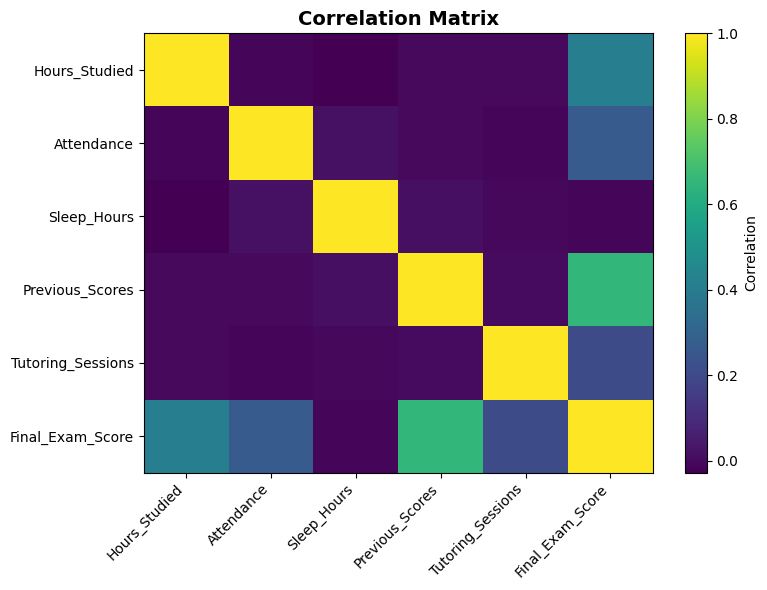

In [18]:
correlation_matrix = df.corr(numeric_only=True)

print("Correlation with Final Exam Score:")
display(
    correlation_matrix['Final_Exam_Score']
    .sort_values(ascending=False)
    .to_frame('correlation_with_final_exam_score')
)

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 18: Skewness and Kurtosis

In [ ]:
analysis_columns = ['Final_Exam_Score', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']

shape_stats = pd.DataFrame({
    'skewness': df[analysis_columns].skew(numeric_only=True),
    'kurtosis': df[analysis_columns].kurt(numeric_only=True)
})

display(shape_stats)

## Step 19: Final Analytical Statement

This exploratory analysis showed how student performance can be evaluated from different perspectives.  
The dataset was grouped by study hour ranges and categorical student characteristics, allowing the comparison of average final exam scores across different profiles.

The analysis also included distribution plots, scatter plots, boxplots, and correlation analysis. These steps help identify patterns between academic performance and variables such as hours studied, attendance, previous scores, motivation level, internet access, access to resources, and tutoring sessions.

Overall, this notebook complements the data cleaning stage by transforming the cleaned dataset into an analysis-ready workflow focused on interpretation, comparison, and visual evidence.

# Student Performance Dataset - Relationship Between Variables

This notebook applies Exploratory Data Analysis (EDA) techniques to investigate relationships between variables in the Student Performance dataset.

The analysis focuses on:
- descriptive statistics
- grouped analysis
- variable relationships
- distributions
- correlation analysis
- visual interpretation

## 1. Import libraries

In [1]:

pd.set_option('display.max_columns', None)

## 2. Load dataset

In [2]:

dataset_file = "student_cleaned.csv"

if not os.path.exists(dataset_file):
    raise FileNotFoundError("Dataset file not found.")

df = pd.read_csv(dataset_file)

print(f"Loaded file: {dataset_file}")
print(f"Shape: {df.shape}")

display(df.head())

Loaded file: student_cleaned.csv
Shape: (6607, 11)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7


## 3. Dataset overview

The first step of EDA is understanding the structure of the dataset.
This includes:
- variable types
- missing values
- duplicated rows
- general dataset dimensions

In [3]:
print("Dataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicated rows:")
print(df.duplicated().sum())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   float64
 1   Attendance                  6607 non-null   float64
 2   Parental_Involvement        6607 non-null   str    
 3   Access_to_Resources         6607 non-null   str    
 4   Extracurricular_Activities  6607 non-null   str    
 5   Sleep_Hours                 6607 non-null   float64
 6   Previous_Scores             6607 non-null   float64
 7   Motivation_Level            6607 non-null   str    
 8   Internet_Access             6607 non-null   str    
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Final_Exam_Score            6607 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 567.9 KB

Missing values:


,missing_values
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0



Duplicated rows:
0


## 4. Descriptive statistics

The describe() function provides:
- mean
- standard deviation
- quartiles
- minimum and maximum values

These statistics help understand central tendency and dispersion.

In [4]:
summary = df.describe().T

display(summary)

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,20.472726,5.988729,1.1,16.5,20.5,24.5,44.0
Attendance,6607.0,79.979068,11.547717,60.0,70.0,79.8,90.2,100.0
Sleep_Hours,6607.0,7.185273,1.290241,4.0,6.3,7.2,8.1,10.0
Previous_Scores,6607.0,74.716059,14.451962,50.0,62.1,74.6,87.4,100.0
Tutoring_Sessions,6607.0,1.488119,1.216175,0.0,1.0,1.0,2.0,8.0
Final_Exam_Score,6607.0,60.400333,8.739400,29.7,54.3,60.4,66.6,95.2


## 5. Frequency grouping (binning)

Hours studied are grouped into intervals (bins) to facilitate comparison between student profiles.

In [5]:
bins = [0, 10, 20, 30, 40, np.inf]
labels = ['0-9', '10-19', '20-29', '30-39', '40+']

df['Study_Group'] = pd.cut(
    df['Hours_Studied'],
    bins=bins,
    labels=labels,
    right=False
)

print(df['Study_Group'].value_counts().sort_index())

Study_Group
0-9       268
10-19    2796
20-29    3160
30-39     380
40+         3
Name: count, dtype: int64


## 6. Grouped analysis by study hours

This table summarizes:
- average final score
- average attendance
- average sleep hours
- average previous scores

for each study hour group.

In [6]:
study_summary = (
    df.groupby('Study_Group', observed=True)
    .agg(
        student_count=('Final_Exam_Score', 'count'),
        avg_exam_score=('Final_Exam_Score', 'mean'),
        avg_attendance=('Attendance', 'mean'),
        avg_sleep_hours=('Sleep_Hours', 'mean'),
        avg_previous_scores=('Previous_Scores', 'mean')
    )
    .reset_index()
)

display(study_summary)

,Study_Group,student_count,avg_exam_score,avg_attendance,avg_sleep_hours,avg_previous_scores
0,0-9,268,52.105224,80.164925,7.371642,73.313806
1,10-19,2796,57.815272,80.054971,7.203362,74.916702
2,20-29,3160,62.587753,79.912057,7.153354,74.733101
3,30-39,380,66.997632,79.834474,7.191316,74.126316
4,40+,3,70.966667,81.533333,6.533333,69.733333


## 7. Relationship between motivation and performance

This grouped analysis compares motivation levels with academic performance.

In [9]:
motivation_summary = (
    df.groupby('Motivation_Level', observed=True)
    .agg(
        avg_exam_score=('Final_Exam_Score', 'mean'),
        avg_hours_studied=('Hours_Studied', 'mean'),
        avg_attendance=('Attendance', 'mean')
    )
    .reset_index()
)

display(motivation_summary)

,Motivation_Level,avg_exam_score,avg_hours_studied,avg_attendance
0,High,63.938473,20.614521,79.822380
1,Low,57.541645,20.390822,80.042493
2,Medium,60.595747,20.462374,80.005582


## 8. Histogram - Final exam score distribution

Histograms help identify:
- central tendency
- dispersion
- skewness
- concentration of observations

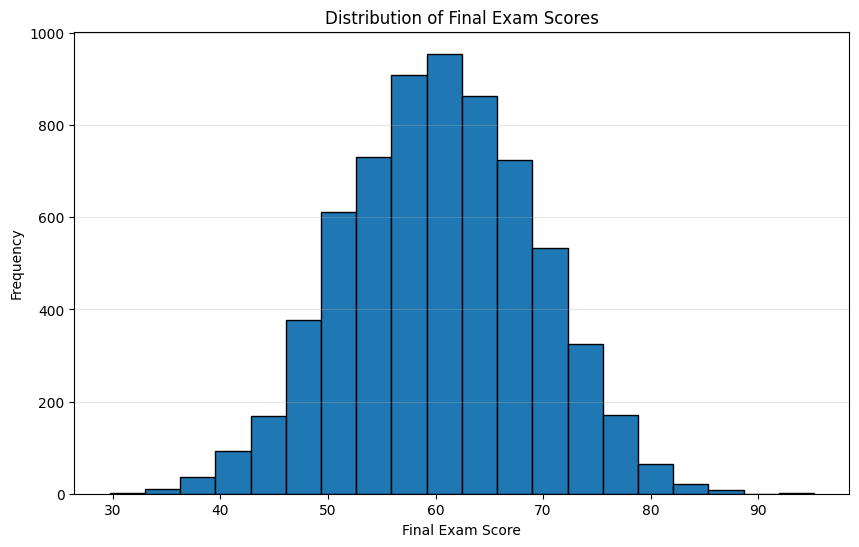

In [8]:
plt.figure(figsize=(10,6))

plt.hist(
    df['Final_Exam_Score'].dropna(),
    bins=20,
    edgecolor='black'
)

plt.title('Distribution of Final Exam Scores')
plt.xlabel('Final Exam Score')
plt.ylabel('Frequency')

plt.grid(axis='y', alpha=0.3)
plt.show()

## 9. Bar plot - Average score by study group

This visualization compares the average final exam score across study hour intervals.

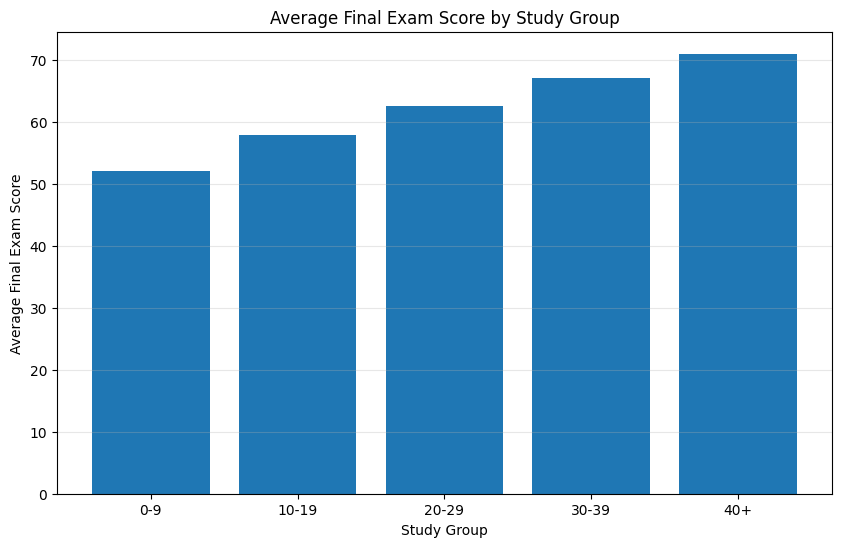

In [9]:
plt.figure(figsize=(10,6))

plt.bar(
    study_summary['Study_Group'].astype(str),
    study_summary['avg_exam_score']
)

plt.title('Average Final Exam Score by Study Group')
plt.xlabel('Study Group')
plt.ylabel('Average Final Exam Score')

plt.grid(axis='y', alpha=0.3)
plt.show()

## 10. Scatter plot - Study hours vs final exam score

Scatter plots help identify:
- relationships between variables
- trends
- possible correlations
- outliers

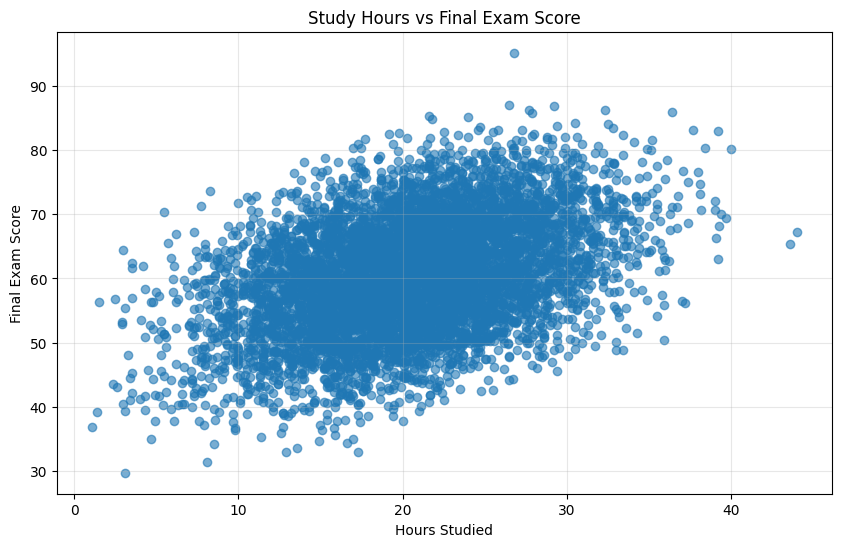

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Hours_Studied'],
    df['Final_Exam_Score'],
    alpha=0.6
)

plt.title('Study Hours vs Final Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Final Exam Score')

plt.grid(alpha=0.3)
plt.show()

## 11. Correlation analysis

Correlation measures how variables vary together.

Values close to:
- 1 indicate strong positive correlation
- -1 indicate strong negative correlation
- 0 indicate weak or no correlation

In [11]:
correlation_matrix = df.corr(numeric_only=True)

display(correlation_matrix)

print("\nCorrelation with Final Exam Score:")

display(
    correlation_matrix['Final_Exam_Score']
    .sort_values(ascending=False)
    .to_frame('correlation_with_final_exam_score')
)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Final_Exam_Score
Hours_Studied,1.000000,-0.010350,-0.028068,-0.003614,-0.002372,0.409850
Attendance,-0.010350,1.000000,0.018120,-0.002012,-0.012405,0.266152
Sleep_Hours,-0.028068,0.018120,1.000000,0.015483,-0.004081,-0.012736
Previous_Scores,-0.003614,-0.002012,0.015483,1.000000,0.003964,0.653388
Tutoring_Sessions,-0.002372,-0.012405,-0.004081,0.003964,1.000000,0.207310
Final_Exam_Score,0.409850,0.266152,-0.012736,0.653388,0.207310,1.000000



Correlation with Final Exam Score:


,correlation_with_final_exam_score
Final_Exam_Score,1.000000
Previous_Scores,0.653388
Hours_Studied,0.409850
Attendance,0.266152
Tutoring_Sessions,0.207310
Sleep_Hours,-0.012736


## 12. Final observations

The exploratory analysis identified relationships between study habits and student performance.

The results suggest that variables such as:
- study hours
- attendance
- previous scores
- motivation

may influence final academic performance.

The notebook demonstrates how EDA techniques can support interpretation and understanding of relationships between variables before predictive modeling.

1. Distribution (univariate)

Selected variable: Final_Exam_Score

Distribution description:
The histogram suggests an approximately symmetric distribution, with most scores concentrated around the center and no strong outliers.

Hypothesis:
H0: Final_Exam_Score follows an approximately normal distribution.
H1: Final_Exam_Score deviates from normality.

2. Relationship (bivariate)

Selected variables: Hours_Studied and Final_Exam_Score

Observed pattern:
The analysis suggests a positive association between study hours and final exam scores.

Hypothesis:
H0: There is no association between Hours_Studied and Final_Exam_Score.
H1: There is an association between Hours_Studied and Final_Exam_Score.